#### アンサンブル法

様々な分類機を1つのメタ分類機として組み合わせ

分類機を個別に使うよりも高い汎化性能が得られる。


***
##### 多数決(majority voting)



<p><img src="ch07/images/07_01.png" width = "39%"/></p> 

考え方

訓練データセットを使って、まずm種類の分類器$C_1,\dots C_m$の訓練を行う。
個々の分類機で予測されたクラスラベルをまとめ、最も得票の多いクラスラベル$\hat{y}$を選択する。


手法(決定木、SVM, ロジスティック回帰等)を変えるか、分類アルゴリズムは同一で訓練データセットの異なる部分を学習させても良い。

典型例がランダムフォレストアルゴリズム



<p><img src="ch07/images/07_02.png" width = "39%"/></p>



アンサンブル法が単独よりも高い性能を得る理由

単独での誤り率を$\varepsilon$とする。
分類器がN個あるとき、最終予測も誤る確率は N/2個以上で誤りが発生する確率

$
P(y\geq k) = \sum_{k\in n}{}_nC_k\varepsilon^k (1-\varepsilon)^{n-k}
$

例: n=10とすると、6個が誤り　+ 7個(〃) + ... + 10個(〃)
に相当。


$\varepsilon=0.25, n=11$の場合　 0.034



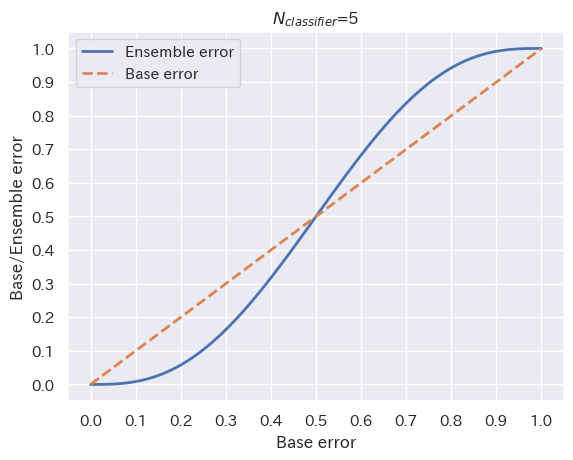

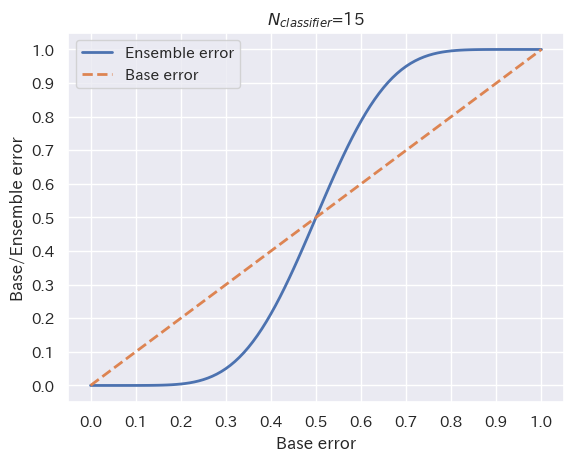

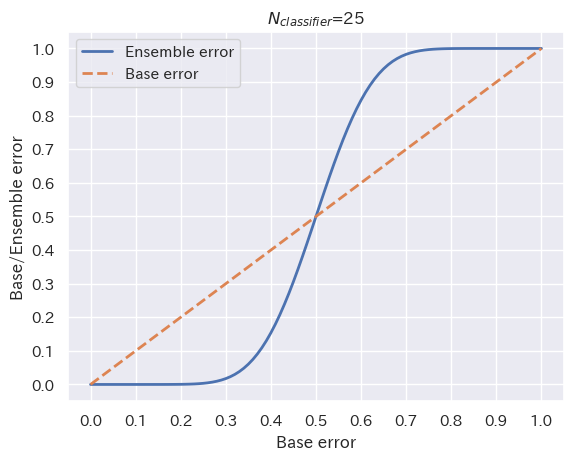

In [19]:
from scipy.special import comb
import math

def ensemble_error(n_classifier, error):
    k_start = int(math.ceil(n_classifier / 2.))
    probs = [comb(n_classifier, k) * error**k * (1-error)**(n_classifier - k)
             for k in range(k_start, n_classifier + 1)]
    return sum(probs)

import numpy as np


for i in range(3):

  n_clss = 10*i + 5
  error_range = np.arange(0.0, 1.01, 0.01)
  ens_errors = [ensemble_error(n_classifier=n_clss, error=error)
              for error in error_range]

  import matplotlib.pyplot as plt
  import seaborn as sns; sns.set()

  plt.plot(error_range, 
          ens_errors, 
          label='Ensemble error', 
          linewidth=2)

  plt.plot(error_range, 
          error_range, 
          linestyle='--',
          label='Base error',
          linewidth=2)
  plt.title("$N_{classifier}$=%s"%(n_clss))
  plt.xlabel('Base error');plt.ylabel('Base/Ensemble error')
  plt.xticks(np.arange(0,1.01,0.1));plt.yticks(np.arange(0,1.01,0.1))
  plt.legend(loc='upper left')
  plt.grid(alpha=1)
  #plt.savefig('images/07_03.png', dpi=300)
  plt.show()

In [38]:
from ch07.MajorityVoteClassifier import MajorityVoteClassifier

from sklearn import datasets

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

iris = datasets.load_iris()

X, y = iris.data[50:, [1,2]], iris.target[50:]

le = LabelEncoder()
y = le.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.5, random_state = 1, stratify = y)


from scipy.special import comb
import math
import numpy as np
import matplotlib.pyplot as plt
from sklearn.base import BaseEstimator
from sklearn.base import ClassifierMixin
from sklearn.preprocessing import LabelEncoder
from sklearn.base import clone
from sklearn.pipeline import _name_estimators
import operator
from sklearn import datasets
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier 
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score
from sklearn.metrics import roc_curve
from sklearn.metrics import auc
from itertools import product
from sklearn.model_selection import GridSearchCV
import pandas as pd
from sklearn.ensemble import BaggingClassifier
from sklearn.metrics import accuracy_score
from sklearn.ensemble import AdaBoostClassifier


clf1 = LogisticRegression(penalty = 'l2', C=0.001, solver = 'lbfgs', random_state = 1)
clf2 = DecisionTreeClassifier(max_depth = 1, criterion = 'entropy', random_state = 0)
clf3 = KNeighborsClassifier(n_neighbors= 1, p=2, metric='minkowski')

pipe1 = Pipeline([['sc',StandardScaler()],['clf', clf1]])
pipe3 = Pipeline([['sc',StandardScaler()],['clf', clf3]])
mv_clf = MajorityVoteClassifier(classifiers=[pipe1, clf2, pipe3])

clfs ={
  'Logistic Regression': pipe1,
  'Decision Tree': clf2,
  'KNN': pipe3,
  'Majority Voting': mv_clf
}

print('10-fold cross validation:\n')
for label, clf  in clfs.items():
  scores = cross_val_score(
    estimator = clf,
    X = X_train,
    y = y_train,
    cv = 10,
    scoring = 'roc_auc'
  )
  print("%20s\t ROC AUC: %0.2f (+/- %0.2f)"%(label,scores.mean(), scores.std()))


10-fold cross validation:

 Logistic Regression	 ROC AUC: 0.92 (+/- 0.15)
       Decision Tree	 ROC AUC: 0.87 (+/- 0.18)
                 KNN	 ROC AUC: 0.85 (+/- 0.13)
     Majority Voting	 ROC AUC: 0.98 (+/- 0.05)


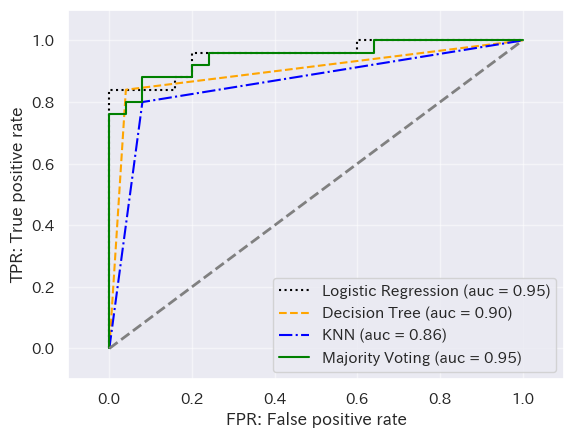

In [48]:
colors = ['black', 'orange', 'blue', 'green']
linestyles = [':','--',"-.",'-' ]

for idx, (label, clf) in enumerate(clfs.items()):

  y_pred = clf.fit(X_train, y_train).predict_proba(X_test)[:,1]
  fpr, tpr, thresholds = roc_curve(y_true = y_test, y_score = y_pred)
  roc_auc = auc(x=fpr, y=tpr)
  
  plt.plot(fpr, tpr, color = colors[idx], linestyle = linestyles[idx], label = '%s (auc = %.02f)'%(label, roc_auc))


plt.legend(loc='lower right')
plt.plot([0, 1], [0, 1],
         linestyle='--',
         color='gray',
         linewidth=2)

plt.xlim([-0.1, 1.1])
plt.ylim([-0.1, 1.1])
plt.grid(alpha=0.5)

plt.xlabel("FPR: False positive rate")
plt.ylabel("TPR: True positive rate")

plt.show()